For question 3, the research question i have chosen is question 5, How do choices about data such as i) amount of training data and ii) balance of classes in a
classification problem affect the performance of a neural network?

I will be seperating this notebook into 2 halves, half i testing the amount of training data and half ii testing the balance of the classes. 

To start, we need the same imports used in notebook 2. We'll start off with the system import packages that make it possible to call functions from other files:

In [1]:
#system imports - chatgpt suggestion
import sys
import os
sys.path.append(os.path.abspath(".."))

Next, we need to import the same packages as the previous notebooks. Pandas allows us to store the data in a dataframe, numpy is for mathematical functions, matplotlib and seaborn handle data visualization and display, and the sklearn imports allow us to analyse the accuracy of the neural network we create.

In [2]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

We also need our helper functions. For part i, we can reuse the functions used in question 2, but for part ii we have had to create a new function to imbalance the classes. The function purposes is commmented next to the function.

In [3]:
from functions import load_data #loads the cleaned penguin size dataset from where it is stored
from functions import split_data #splits the data into training and testing sets
from functions import split_train_test #splits features and labels into training and testing sets
from functions import scale_features #scales the training features using standard scaler
from functions import train_neural_network #trains mlp neural network on training data
from functions import evaluate_neural_network #evaluates the performance of the trained neural network
from functions import imbalance_classes #imbalances classes for question 3 ii


First half - part i

To investigate the impacts of amount of training data on the accuracy of the model, we can redo what we did in notebook 2 but change the proportions of the data split when using the function to split the dataset into training and testing. In notebook 2, we used 80% training data and 20% testing data and got an accuracy of 98.5%. In this investigation, we can proportion the dataset differently then train and test the model to compare their accuracies. We will use different proportions and then compare the results.

As we did in question 2, we need to start by importing and preparing the data. We will use the load_data functions as well as the split_data function to have the data split into target and feature ready to be split into testing and training groups.

In [4]:
#importing data with load_data function
df =load_data("../../data/processed/penguins_size_cleaned.csv") #data loaded in
print(df.head()) #print first 5 rows of the dataframe to verify data loaded correctly

#splitting data into target (species) and features (culmen length, depth, flipper length, body mass)
feature_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g',] #feature variables to use
target_col = 'species' #target variabke to predict - species
x, y = split_data(df, feature_cols, "species") #feature and target variables have been assigned to x and y)

  species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen              39.1             18.7              181.0   
1  Adelie  Torgersen              39.5             17.4              186.0   
2  Adelie  Torgersen              40.3             18.0              195.0   
3  Adelie  Torgersen              36.7             19.3              193.0   
4  Adelie  Torgersen              39.3             20.6              190.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3       3450.0  FEMALE  
4       3650.0    MALE  


Next, we encode the target variables into numbers again:

In [5]:
#using the label encoder to give target values numerical values
labels = LabelEncoder() #calling the label encoder from sklearn
y = labels.fit_transform(y) #encoding the species labels into numerical values
print("Encoded species labels:", labels.classes_) #printing the encoded species labels for later
#adelie = 0, chinstrap = 1, gentoo = 2

Encoded species labels: ['Adelie' 'Chinstrap' 'Gentoo']


One important thing to note is that the accuracy percentage is not equal in each case as the proportion of training/test data is varying, so the accuracy score may incorrectly represent how well it performed relative to other versions, so when comparing the differences the number of incorrect predictions shows a more accurate picture.

Now that we have the data split into target and feature groups, we need to split it into training and testing, use it to train the model, then find the accuracy just as we did in notebook 2. In notebook 2, we did 80/20 which gave us 98.5% accuracy, so we can expect to get lower accuracies from smaller training sets. In this notebook, we will test training/test splits of 5/95, 20/80, 40/60, 50/50, 60,40, 80/20 and 95/5 and find the accuracy and confusion matrix for each, then compare the proportions to see how the training set size impacts model accuracy. Starting with 9/95, we will first split the training set:

In [64]:
#splitting the data into training and testing sets in the proportion 5:95 
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.95, random_state = 42)

Now we need to follow the same process from notebook 2. The scaling of the training data so that the model can compare each equally comes next:

In [65]:
#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

The last thing to do before training the neural networks is to create a series of lists to make data comparison easier a bit later on. We will the append the data split, accuracy percentage and number of incorrect predictions to these lists to make plotting a table quick and easy.

In [70]:
#lists for later use
data_split = ["5/95", "20/80", "40/60", "50/50", "60/40", "80/20", "95/5"] #list of data splits
accuracy_score = []
incorrect_predictions = []

We can now create and train the neural network on this data. As the training data is a very small fraction of the whole dataset, we can assume it will not be as accurate. After training it, we can use the evaluation function to see how accurate it really is and plot the confusion matrix to see where it is getting mixed up.

In [71]:
#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)


In [72]:
#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9661538461538461
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       142
           1       0.92      0.91      0.91        65
           2       1.00      1.00      1.00       118

    accuracy                           0.97       325
   macro avg       0.96      0.96      0.96       325
weighted avg       0.97      0.97      0.97       325



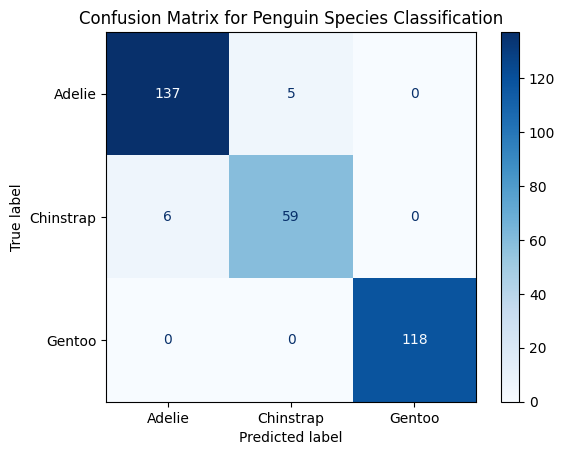

In [73]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_01_0595.png")
plt.show()

Trained on 5% of the data and tested on 95%, the neural network performed quite well. It has an accuracy of 96.6% and performed perfectly predicting the gentoo penguins. In question 2, the model struggled predicting adelie and chinstrap penguins but was only incorrect once, compared to 11 times here. This suggests that the proportion of training data really is important to prediction accuracy, although even at 5/95 the model performed fairly well. We will now repeat this experiment for 20/80, 40/60, 50/50, 60/40 and 80/20.

In [74]:
#training neural network on 20/80 split

#splitting the data into training and testing sets in the proportion 20:80
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.80, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9817518248175182
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       125
           1       0.96      0.94      0.95        51
           2       1.00      1.00      1.00        98

    accuracy                           0.98       274
   macro avg       0.98      0.98      0.98       274
weighted avg       0.98      0.98      0.98       274



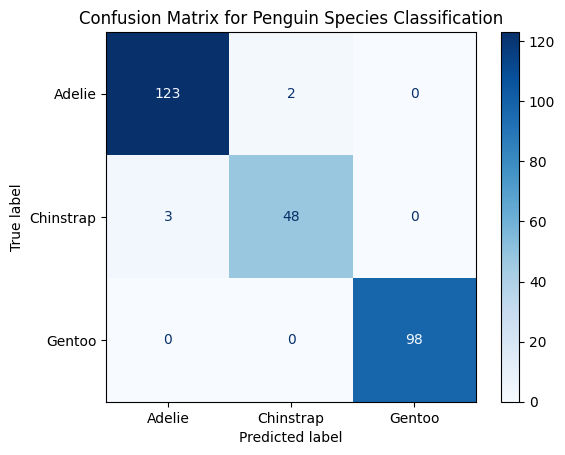

In [75]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_02_2080.png")
plt.show()

When trained on 20% of the data, the model preforms better than the previous perfomance at 5%. Once again, there is no incorrect predictions for gentoo penguins and the numbers of incorrect predictions for adelie and chinstrap penguins has decreases to 5 total. This model version has an accuracy score of 98.17%.

In [76]:
#training neural network on 40/60 split

#splitting the data into training and testing sets in the proportion 40:60
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.60, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9902912621359223
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99        92
           1       0.97      0.97      0.97        37
           2       1.00      1.00      1.00        77

    accuracy                           0.99       206
   macro avg       0.99      0.99      0.99       206
weighted avg       0.99      0.99      0.99       206



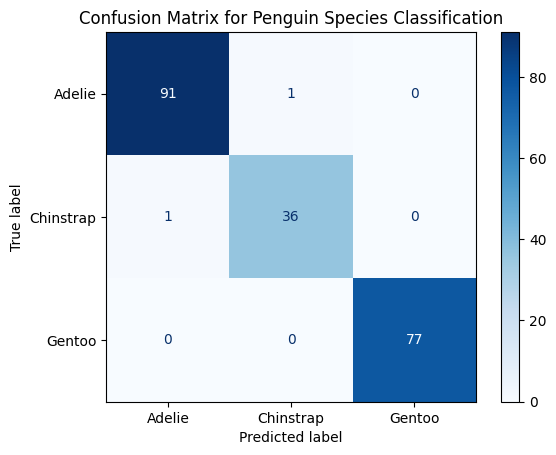

In [77]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_03_4060.png")
plt.show()

This version of the model performed very well, only making 2 incorrect predictions and getting an accuracy score of 99%. It also got confused in the same places the other models did.

In [78]:
#training neural network on 50/50 split

#splitting the data into training and testing sets in the proportion 50:50
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.50, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9883040935672515
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99        79
           1       0.97      0.97      0.97        29
           2       1.00      1.00      1.00        63

    accuracy                           0.99       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.99      0.99      0.99       171



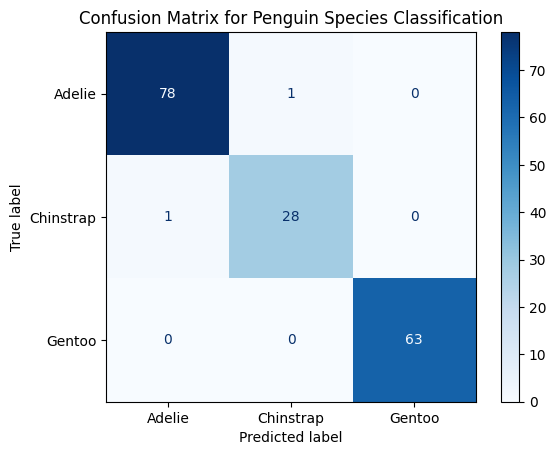

In [79]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_04_5050.png")
plt.show()

This version performed very similarly to the previous version (40/60), with the same 2 incorrect predictions to get an accuracy score of 98.8%. The proportion of test data is smaller here so the accuracy has dropped due to the same number of incorrect predictions taking up a little bit more space.

In [80]:
#training neural network on 60/40 split

#splitting the data into training and testing sets in the proportion 60:40
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.40, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9927007299270073
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        64
           1       0.96      1.00      0.98        24
           2       1.00      1.00      1.00        49

    accuracy                           0.99       137
   macro avg       0.99      0.99      0.99       137
weighted avg       0.99      0.99      0.99       137



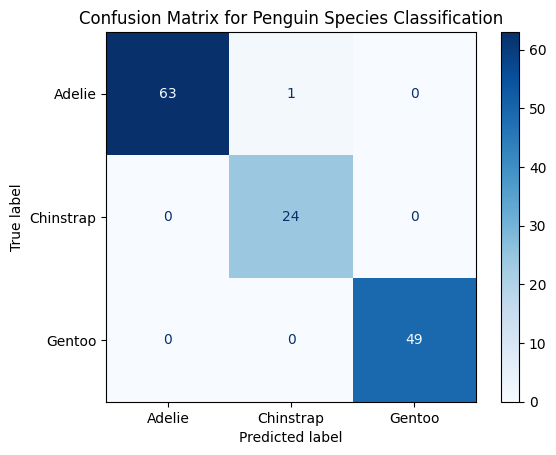

In [81]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_05_6040.png")
plt.show()

This version of the model only made one incorrect prediction and is getting better at differentiating between adelie penguins and chinstrap penguins. the accuracy for this version is 99.3%.

In [82]:
#training neural network on 80/20 split

#splitting the data into training and testing sets in the proportion 80:20
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.20, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 0.9855072463768116
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        35
           1       0.92      1.00      0.96        12
           2       1.00      1.00      1.00        22

    accuracy                           0.99        69
   macro avg       0.97      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69



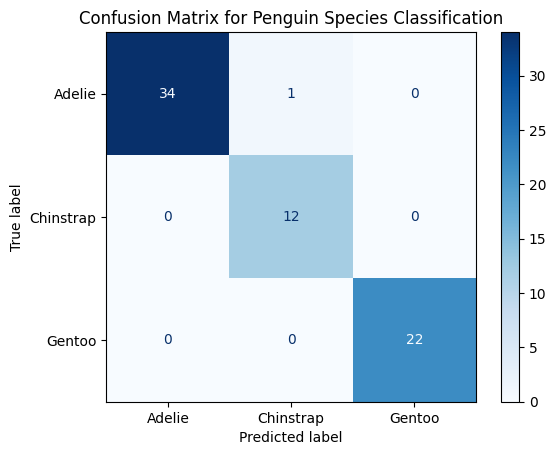

In [83]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_06_8020.png")
plt.show()

This version of the model performs the same as the previous version, with only one incorrect prediction to give an accuracy score of 98.6%

In [84]:
#training neural network on 95/5 split

#splitting the data into training and testing sets in the proportion 95:5
x_train, x_test, y_train, y_test = split_train_test(x, y, test_size = 0.05, random_state = 42)

#scaling the test data using scale_features function
x_train_scaled, x_test_scaled = scale_features(x_train, x_test) #returns scaled training and testing feature data

#creating and training neural network
mlp = train_neural_network(x_train_scaled, y_train, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the performance of the neural network using the test data
accuracy, report = evaluate_neural_network(mlp, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy) #printing the accuracy
print("Classification Report:\n", report) #printing the classification report

#appending accuracy score and incorrect predictions to list
accuracy_score.append(accuracy) #appending accuracy to list
incorrect_predictions.append(len(y_test) - int(accuracy * len(y_test))) #appending number of incorrect predictions to list

Accuracy of the neural network:
 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         6

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



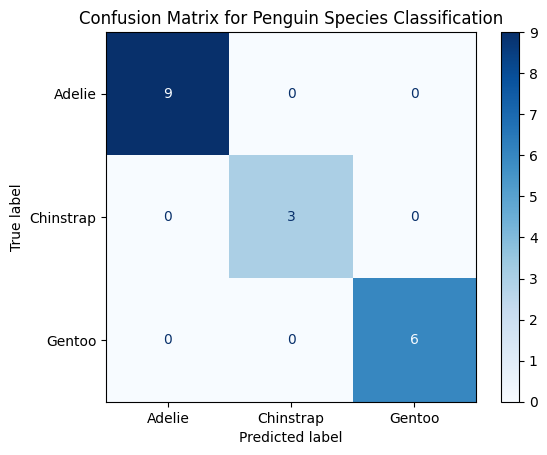

In [85]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, mlp.predict(x_test_scaled), labels=mlp.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_07_9505.png")
plt.show()

With this proportion of the data, the model is 100% accurate and makes no incorrect predictions.

Now that we have all the data from the different versions of the model, we can draw some conclusions on how the model works trained on different amounts of data. The MLP neural network naturally has very good performance, even when trained on a small proportion of the dataset. We can now use pandas to create a table showing the data split, percentage accuracy for each model and the number of incorrect predictions.

In [89]:
#using pandas to create a dataframe of our findings for easy comparisons
results_df = pd.DataFrame({"Data Split": data_split, "Incorrect Predictions": incorrect_predictions, "Accuracy": accuracy_score, })
results_df #displaying dataframe

,Data Split,Incorrect Predictions,Accuracy
0,5/95,11,0.966154
1,20/80,5,0.981752
2,40/60,2,0.990291
3,50/50,2,0.988304
4,60/40,1,0.992701
5,80/20,1,0.985507
6,95/5,0,1.000000


Looking at the table above, we can see that the accuracy trends upwards with a couple exceptions at 50/50 and 80/20, which are a little lower than the ones before them. Both the 50/50 and 80/20 model versions perform the same as the model before them in terms of incorrect predictions, but due to their smaller testing sets, the incorrect predictions seem larger and cause a larger accuracy decrease. Looking at the incorrect predictions columns, we can see that the more data the model is trained on, the more accurate the model becomes. For example, when trained on 5% of the data and tested on 95%, 11 incorrect predictions were made, however when trained on 95% of the data and tested on 5%, 0 incorrect predictions were made. The largest jump was between 5% training data to 20% training data, where 6 incorrect predictions were fixed.

The dataset I chose for this investigation was quite small, so the proportions of data were all fairly small. If the dataset chosen was larger, the 5% set of training data would have been larger and the model would have had more data samples to train on, so would likely have been more accurate. I expected the dataset to be less accurate at 5% and 20%, but the mlp neural network chosen for this is very well suited to the data so has very good accuracy even when trained at low training data percentages.

second half - part ii

In [46]:
#imports to ignore warnings for extreme datasets 
#code copied and pasted from chatgpt to remove warnings coming up when data classes were messed with in
#extreme ways
from sklearn.exceptions import UndefinedMetricWarning
import warnings
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

For the second half of this notebook, we will explore how the balance of classes used in the training data impacts the accuracy of the neural network. I have created and imported a new helper function for this called imbalance_classes, which imbalances specified classes based on proportions we will choose. 

To start, we will look at how many samples exist for each class in the current dataset:

In [6]:
#checking the number of each class
y = pd.Series(y) #changing the classes to be compatible with pandas - chatgpt correction
y.value_counts() #finding the number of each class

0    151
2    123
1     68
Name: count, dtype: int64

We can see that the classes arent perfectly balanced in this dataset - there is about half the information on gentoo penguins compared to adelie (which has the most), and chinstrap. We can start preparing the data for this by splitting the data into a training/test set in the proportion we used in notebooks 1 and 2, 80/20. Then, we can use the imbalance_classes function to alter the class balance in the training group while leaving the test group alone, and look at how the accuracies of the predictions change. The premade split function from sklearn has an extra characteristic that our function doesn't that keeps the classes balanced, so we will import and use their function to ensure that the random distribution is not impacting our accuracy.

In [15]:
#splitting the data into training and testing groups
from sklearn.model_selection import train_test_split #importing premade feature from sklearn
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(y_train.value_counts()) #checking target training data

0    121
2     98
1     54
Name: count, dtype: int64


We will now use our helper function to imbalance the classes and check predictions. We will imbalance each of the three classes with 2%, 10% and 50% of the original data and then compare the accuracy increases in each class.

The model here was trained on 2% of the total training data for class 0 (adelie) penguins. This caused the accuracy to drop to 72%, far lower than we have ever seen it before. The model has been confused between class 0 and class 1 penguins a lot, so reducing the sample size of class 0 has also impacted class 1 massively. While the model was able to predict class 0 correctly every time, it was unable to do the same for the other two penguin species. On the other hand, the other 2 were recalled perfectly, compared to the recall score of 0.37 for class 0. The imbalance of classes here has caused a drop in accuracy of over 20% from an 80/20 split with no class imbalance, calculated as 98.5% previously.

In [52]:
#imbalancing the classes using the helper function
x_imbalanced, y_imbalanced = imbalance_classes(x_train, y_train, classes_to_reduce=[0], reduction_fraction=0.98, random_state=42)
y_imbalanced.value_counts() #looking at the value counts for target training data

2    98
1    54
0     2
Name: count, dtype: int64

Comparing this to the value checking we got when we checked before imbalancing the data, we can see that for class 0 (adelie penguins), the sample count has gone from 121 to 1 so has reduced by 99%. We can now go through the same steps as above in i to create and train the neural network then find its accuracy, starting off by scaling the data.

In [53]:
#scaling the data using the scale_features function
x_imablanced_train_scaled, x_test_scaled = scale_features(x_imbalanced, x_test) #scaling the imbalanced training data

We will now replicate the above steps of training the mlp then generating an accuracy report:

In [54]:
#creating and training the mlp
mlp_imbalanced = train_neural_network(x_imablanced_train_scaled, y_imbalanced, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the accuracy of the imbalanced mlp
accuracy_imbalanced, report_imbalanced = evaluate_neural_network(mlp_imbalanced, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy_imbalanced) #printing the accuracy
print("Classification Report:\n", report_imbalanced) #printing the classification report


Accuracy of the neural network:
 0.9130434782608695
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89        30
           1       0.74      1.00      0.85        14
           2       0.96      1.00      0.98        25

    accuracy                           0.91        69
   macro avg       0.90      0.93      0.91        69
weighted avg       0.93      0.91      0.91        69



The model here was trained on 2% of the total training data for class 0 (adelie) penguins. This caused the accuracy to drop to 91%, lower than we have ever seen it before. The model has been confused between class 0 and class 1 penguins a lot, so reducing the sample size of class 0 has also impacted class 1 massively. While the model was able to predict class 0 correctly every time, it was unable to do the same for the other two penguin species. On the other hand, the other 2 were recalled perfectly, compared to the recall score of 0.80 for class 0. The imbalance of classes here has caused a drop in accuracy of over 7% from an 80/20 split with no class imbalance, calculated as 98.5% previously.

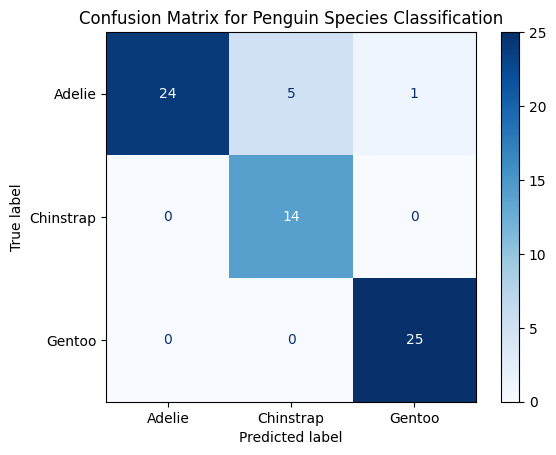

In [56]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, y_pred = mlp_imbalanced.predict(x_test_scaled), labels=mlp_imbalanced.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_ii_01_002.png")
plt.show()

The confusion matrix shows us that this model was inaccurate compared to the balanced models with the same split, making incorrect predictions 5 times.

We can now repeat this for 10% and 50% fractions for class 0 and find their accuracies:

In [32]:
#imbalancing the classes using the helper function
x_imbalanced, y_imbalanced = imbalance_classes(x_train, y_train, classes_to_reduce=[0], reduction_fraction=0.90, random_state=42)
print(y_imbalanced.value_counts()) #looking at the value counts for target training data

#scaling the data using the scale_features function
x_imablanced_train_scaled, x_test_scaled = scale_features(x_imbalanced, x_test) #scaling the imbalanced training data

#creating and training the mlp
mlp_imbalanced = train_neural_network(x_imablanced_train_scaled, y_imbalanced, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the accuracy of the imbalanced mlp
accuracy_imbalanced, report_imbalanced = evaluate_neural_network(mlp_imbalanced, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy_imbalanced) #printing the accuracy
print("Classification Report:\n", report_imbalanced) #printing the classification report

2    98
1    54
0    12
Name: count, dtype: int64
Accuracy of the neural network:
 0.9710144927536232
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.88      1.00      0.93        14
           2       1.00      1.00      1.00        25

    accuracy                           0.97        69
   macro avg       0.96      0.98      0.97        69
weighted avg       0.97      0.97      0.97        69



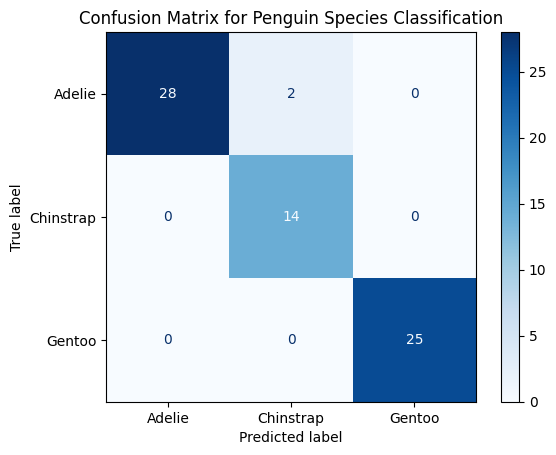

In [33]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, y_pred = mlp_imbalanced.predict(x_test_scaled), labels=mlp_imbalanced.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_ii_01_010.png")
plt.show()

Compared to 1% of the data, 10% trains the model to be far more accurate. Its accuracy percentage is 97% and the confusion matrix shows it only made incorrect predictions twice, once again between the adelie and chinstrap penguins. The performance of the model in predicting gentoo penguins was perfect. The prediction of the adelie penguins was also perfect, but the recall wasn't as accurate. The models performance for chinstrap penguins was the opposite, perfect recall but incorrect predictions.

In [34]:
#imbalancing the classes using the helper function
x_imbalanced, y_imbalanced = imbalance_classes(x_train, y_train, classes_to_reduce=[0], reduction_fraction=0.50, random_state=42)
print(y_imbalanced.value_counts()) #looking at the value counts for target training data

#scaling the data using the scale_features function
x_imablanced_train_scaled, x_test_scaled = scale_features(x_imbalanced, x_test) #scaling the imbalanced training data

#creating and training the mlp
mlp_imbalanced = train_neural_network(x_imablanced_train_scaled, y_imbalanced, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the accuracy of the imbalanced mlp
accuracy_imbalanced, report_imbalanced = evaluate_neural_network(mlp_imbalanced, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy_imbalanced) #printing the accuracy
print("Classification Report:\n", report_imbalanced) #printing the classification report

2    98
0    60
1    54
Name: count, dtype: int64
Accuracy of the neural network:
 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



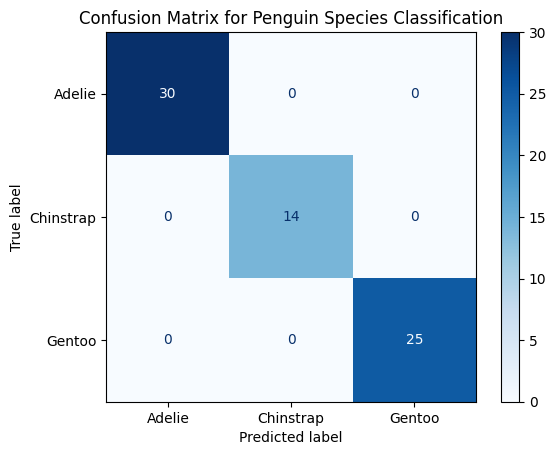

In [35]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, y_pred = mlp_imbalanced.predict(x_test_scaled), labels=mlp_imbalanced.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_ii_01_050.png")
plt.show()

For a 50% reduction, the model has performed perfectly and made completely correct predictions and recalls. The adelie penguins made up the majority of samples within the dataset, so changing the proportion of them still leaves a sample size large enough to train the model fairly well on.

Next, we will repeat these exact same tests for class 1 penguins, or chinstrap penguins.

In [61]:
#imbalancing the classes using the helper function
x_imbalanced, y_imbalanced = imbalance_classes(x_train, y_train, classes_to_reduce=[1], reduction_fraction=0.98, random_state=42)
print(y_imbalanced.value_counts()) #looking at the value counts for target training data

#scaling the data using the scale_features function
x_imablanced_train_scaled, x_test_scaled = scale_features(x_imbalanced, x_test) #scaling the imbalanced training data

#creating and training the mlp
mlp_imbalanced = train_neural_network(x_imablanced_train_scaled, y_imbalanced, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the accuracy of the imbalanced mlp
accuracy_imbalanced, report_imbalanced = evaluate_neural_network(mlp_imbalanced, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy_imbalanced) #printing the accuracy
print("Classification Report:\n", report_imbalanced) #printing the classification report

0    121
2     98
1      1
Name: count, dtype: int64
Accuracy of the neural network:
 0.7971014492753623
Classification Report:
               precision    recall  f1-score   support

           0       0.68      1.00      0.81        30
           1       0.00      0.00      0.00        14
           2       1.00      1.00      1.00        25

    accuracy                           0.80        69
   macro avg       0.56      0.67      0.60        69
weighted avg       0.66      0.80      0.71        69



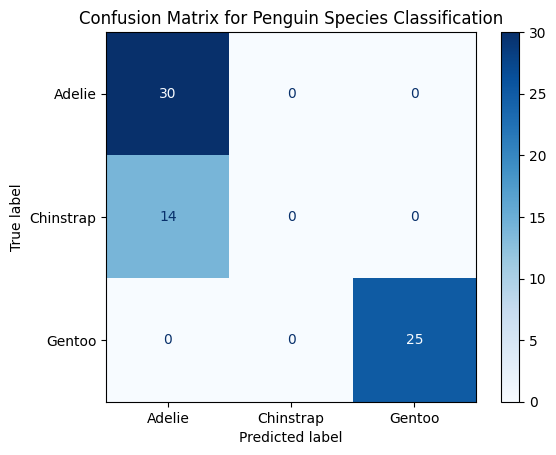

In [62]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, y_pred = mlp_imbalanced.predict(x_test_scaled), labels=mlp_imbalanced.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_ii_02_002.png")
plt.show()

For this version, no correct predictions were for the chinstrap penguins, as shown by the confusion matrix. The gentoo penguins were classified perfectly, but the model got very confused between adelie and chinstrap due to almost no training data on chinstrap penguins, leading to an accuracy score of 79.7%, our lowest accuracy score so far.

In [57]:
#imbalancing the classes using the helper function
x_imbalanced, y_imbalanced = imbalance_classes(x_train, y_train, classes_to_reduce=[1], reduction_fraction=0.90, random_state=42)
print(y_imbalanced.value_counts()) #looking at the value counts for target training data

#scaling the data using the scale_features function
x_imablanced_train_scaled, x_test_scaled = scale_features(x_imbalanced, x_test) #scaling the imbalanced training data

#creating and training the mlp
mlp_imbalanced = train_neural_network(x_imablanced_train_scaled, y_imbalanced, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the accuracy of the imbalanced mlp
accuracy_imbalanced, report_imbalanced = evaluate_neural_network(mlp_imbalanced, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy_imbalanced) #printing the accuracy
print("Classification Report:\n", report_imbalanced) #printing the classification report

0    121
2     98
1      5
Name: count, dtype: int64
Accuracy of the neural network:
 0.9565217391304348
Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95        30
           1       1.00      0.79      0.88        14
           2       1.00      1.00      1.00        25

    accuracy                           0.96        69
   macro avg       0.97      0.93      0.94        69
weighted avg       0.96      0.96      0.95        69



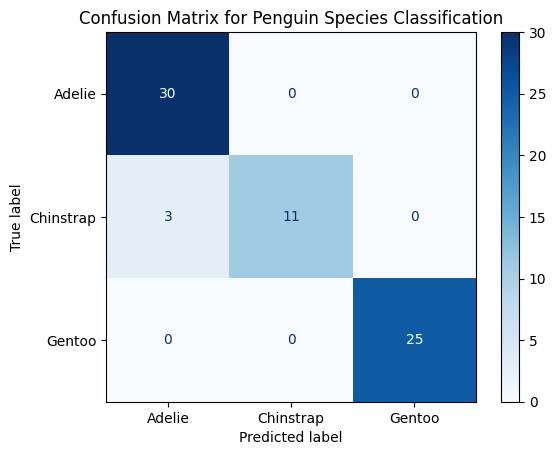

In [58]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, y_pred = mlp_imbalanced.predict(x_test_scaled), labels=mlp_imbalanced.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_ii_02_010.png")
plt.show()

This version of the model has a higher accuracy than the one trained with 2% of the chinstrap data. The accuracy has improved from 79.7% to 95.65% as there was more chinstrap samples to train on, and the number of incorrect predictions and recalls has decreased massively. The model predicted gentoo and chinstrap correctly 100% of the time and recalled gentoo and adelie correctly 100% of the time, but only predicted adelie correctly 91% and recalled chinstrap 79% correctly. This shows that although the model is not highly accurate yet, the accuracy has improved by a lot with a little more data.

In [59]:
#imbalancing the classes using the helper function
x_imbalanced, y_imbalanced = imbalance_classes(x_train, y_train, classes_to_reduce=[1], reduction_fraction=0.50, random_state=42)
print(y_imbalanced.value_counts()) #looking at the value counts for target training data

#scaling the data using the scale_features function
x_imablanced_train_scaled, x_test_scaled = scale_features(x_imbalanced, x_test) #scaling the imbalanced training data

#creating and training the mlp
mlp_imbalanced = train_neural_network(x_imablanced_train_scaled, y_imbalanced, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the accuracy of the imbalanced mlp
accuracy_imbalanced, report_imbalanced = evaluate_neural_network(mlp_imbalanced, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy_imbalanced) #printing the accuracy
print("Classification Report:\n", report_imbalanced) #printing the classification report

0    121
2     98
1     27
Name: count, dtype: int64
Accuracy of the neural network:
 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



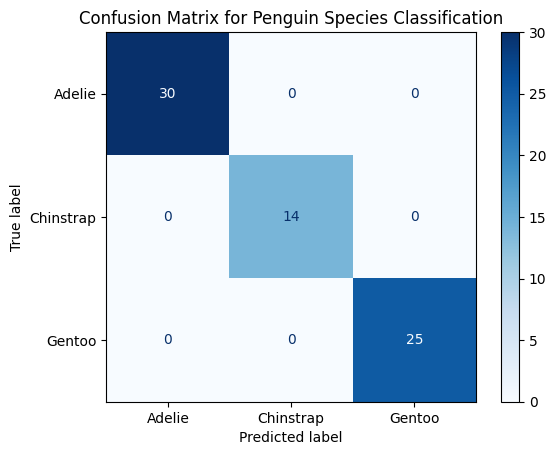

In [60]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, y_pred = mlp_imbalanced.predict(x_test_scaled), labels=mlp_imbalanced.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_ii_02_050.png")
plt.show()

For this version, the accuracy was 100% and the test group was all predicted and recalled correctly.

In [63]:
#imbalancing the classes using the helper function
x_imbalanced, y_imbalanced = imbalance_classes(x_train, y_train, classes_to_reduce=[2], reduction_fraction=0.98, random_state=42)
print(y_imbalanced.value_counts()) #looking at the value counts for target training data

#scaling the data using the scale_features function
x_imablanced_train_scaled, x_test_scaled = scale_features(x_imbalanced, x_test) #scaling the imbalanced training data

#creating and training the mlp
mlp_imbalanced = train_neural_network(x_imablanced_train_scaled, y_imbalanced, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the accuracy of the imbalanced mlp
accuracy_imbalanced, report_imbalanced = evaluate_neural_network(mlp_imbalanced, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy_imbalanced) #printing the accuracy
print("Classification Report:\n", report_imbalanced) #printing the classification report

0    121
1     54
2      1
Name: count, dtype: int64
Accuracy of the neural network:
 0.7246376811594203
Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86        30
           1       0.61      1.00      0.76        14
           2       1.00      0.24      0.39        25

    accuracy                           0.72        69
   macro avg       0.79      0.75      0.67        69
weighted avg       0.81      0.72      0.67        69



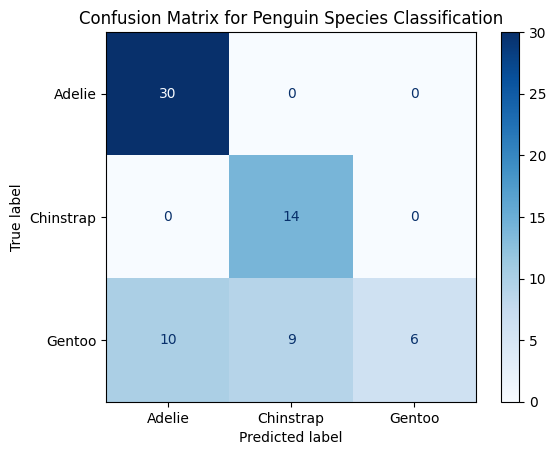

In [64]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, y_pred = mlp_imbalanced.predict(x_test_scaled), labels=mlp_imbalanced.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_ii_03_002.png")
plt.show()

This result is quite surprising, because the model has been far less confused with gentoo penguins before. When trained on only 2% of the gentoo data, the accuracy of the model drops to 72% and predicted the gentoo penguins very incorrectly, as shown on the confusion matrix. We can see 19 incorrect predictions as opposed to 6 correct predictions. The precision for gentoo penguins as perfect as opposed to the lower scores for adelie and chinstrap (due to the misclassification of gentoo penguins), but the recall for gentoo penguins was 0.24. The other two types of penguins were uneffected and had perfect recall.

In [65]:
#imbalancing the classes using the helper function
x_imbalanced, y_imbalanced = imbalance_classes(x_train, y_train, classes_to_reduce=[2], reduction_fraction=0.90, random_state=42)
print(y_imbalanced.value_counts()) #looking at the value counts for target training data

#scaling the data using the scale_features function
x_imablanced_train_scaled, x_test_scaled = scale_features(x_imbalanced, x_test) #scaling the imbalanced training data

#creating and training the mlp
mlp_imbalanced = train_neural_network(x_imablanced_train_scaled, y_imbalanced, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the accuracy of the imbalanced mlp
accuracy_imbalanced, report_imbalanced = evaluate_neural_network(mlp_imbalanced, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy_imbalanced) #printing the accuracy
print("Classification Report:\n", report_imbalanced) #printing the classification report

0    121
1     54
2      9
Name: count, dtype: int64
Accuracy of the neural network:
 0.9710144927536232
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        30
           1       0.93      1.00      0.97        14
           2       1.00      0.96      0.98        25

    accuracy                           0.97        69
   macro avg       0.97      0.98      0.97        69
weighted avg       0.97      0.97      0.97        69



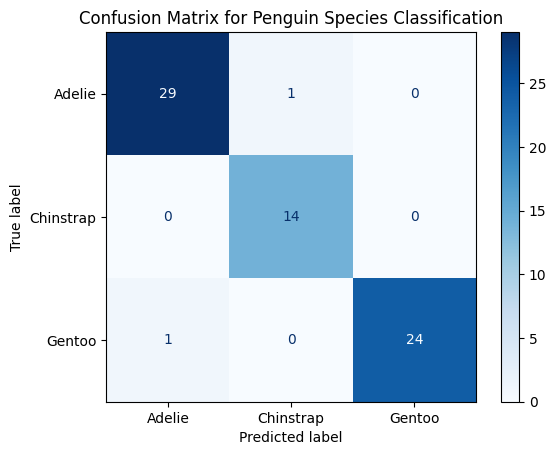

In [66]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, y_pred = mlp_imbalanced.predict(x_test_scaled), labels=mlp_imbalanced.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_ii_03_010.png")
plt.show()

When trained on 10% of the data, the gentoo penguins were much more accurately classified, only being misclassified once. one of the adlie penguins was also misclassified as a chinstrap penguin, however this is probably unrelated to the gentoo penguins being imbalanced. The accuracy for this version of the model is 97.1%, and this model has good prescision for the gentoo penguins (but slightl lower scores for adelie and chinstrap due to the one mix up), and a recall score of 0.96 for the gentoo penguins. Just by increasing the gentoo data from 2% to 10% the number of incorrect predictions has dropped from 19 to 1.

In [67]:
#imbalancing the classes using the helper function
x_imbalanced, y_imbalanced = imbalance_classes(x_train, y_train, classes_to_reduce=[2], reduction_fraction=0.50, random_state=42)
print(y_imbalanced.value_counts()) #looking at the value counts for target training data

#scaling the data using the scale_features function
x_imablanced_train_scaled, x_test_scaled = scale_features(x_imbalanced, x_test) #scaling the imbalanced training data

#creating and training the mlp
mlp_imbalanced = train_neural_network(x_imablanced_train_scaled, y_imbalanced, hidden_layers=(16,16), epochs=1000, random_state=42)

#evaluating the accuracy of the imbalanced mlp
accuracy_imbalanced, report_imbalanced = evaluate_neural_network(mlp_imbalanced, x_test_scaled, y_test)
print("Accuracy of the neural network:\n", accuracy_imbalanced) #printing the accuracy
print("Classification Report:\n", report_imbalanced) #printing the classification report

0    121
1     54
2     49
Name: count, dtype: int64
Accuracy of the neural network:
 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



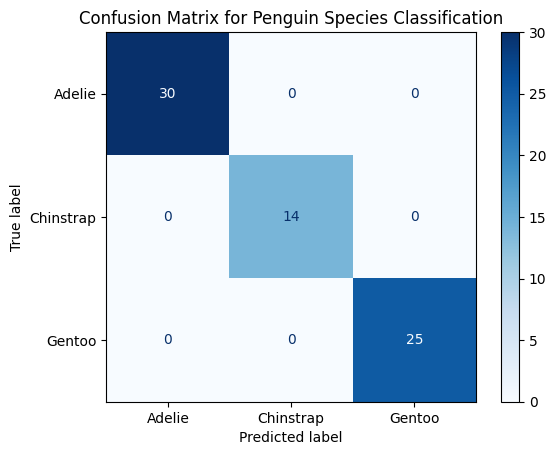

In [68]:
#plotting a confusion matrix for perfomance visualisation
cm = confusion_matrix(y_test, y_pred = mlp_imbalanced.predict(x_test_scaled), labels=mlp_imbalanced.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Penguin Species Classification")
plt.savefig("../../images/03_confusion_matrix_ii_03_050.png")
plt.show()

This version of the model trained on 50% of the gentoo data has a 100% accuracy.

For each of the classes, the accuracy trended upwards when more training data was used and each class was less unbalanced. For the adelie penguins, the impact of using 2% of the training data was lesser due to having the most samples and started off at 91% accuracy compared to 79.7% and 72.4% for the other two groups. Increasing the data to 10% for each class did have a big impact and was helpful however, resulting in accuracy scores of 97.1%, 95.6% and 97.1% for each penguin class respectively. From there, the accuracy of each model increased to 100% when the class was reduced by only 50%.

This shows us that class imbalance does have a large impact on the accuracy of the model. When the class imbalances were larger the model was trained on very few samples, leading to inaccuraces in prediction and recall when tested. This massively reduced when the amount of training data was increased and the classes were less imbalanced. The dataset chosen is slightly flawed in the sense that there is more data samples for adelie penguins compared to gentoo and chinstrap so reducing the amount of adelie data used to train the model had less of an impact compared to the other two, which were trained on one sample when the classes were imbalanced to 2% of their data.

The penguins have biological differences too, adelie and chinstrap are more similar than gentoo penguins so the model tends to get less confused with gentoo penguins.

To conclude, the class balance does effect the model for classification problems, as the accuracy increase was sizeable when comparing a model trained on 2% of the data from one class compared to 50% of the data from one class.